<a href="https://colab.research.google.com/github/nolszewska135/Sztuczna-Inteligencja/blob/main/lab5_21193.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Kształt zbioru treningowego: (2769, 1)
Kształt zbioru testowego: (251, 1)


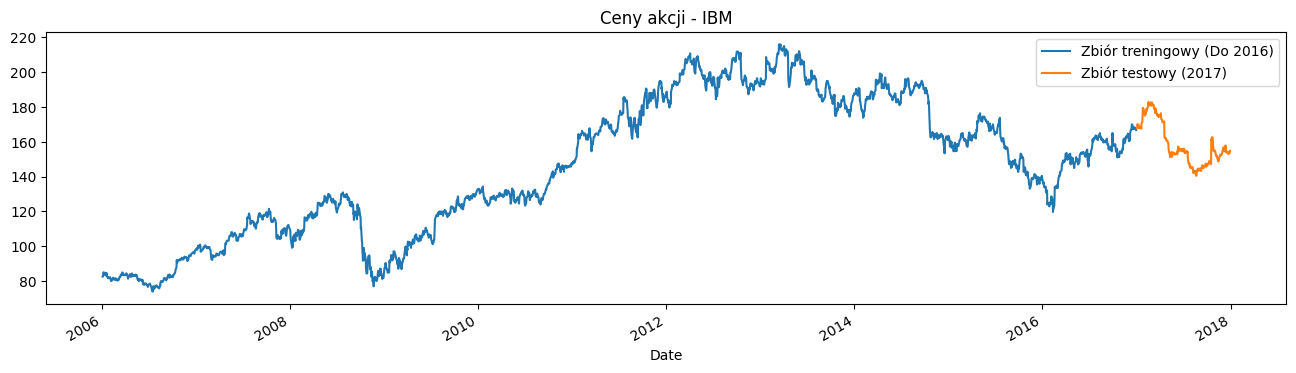

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



--- Rozpoczęcie uczenia sieci LSTM ---
Epoch 1/25
85/85 ━━━━━━━━━━━━━━━━━━━━ 15s 103ms/step - loss: 0.0197
Epoch 2/25
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 117ms/step - loss: 0.0090
Epoch 3/25
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 118ms/step - loss: 0.0083
Epoch 4/25
85/85 ━━━━━━━━━━━━━━━━━━━━ 11s 126ms/step - loss: 0.0071
Epoch 5/25
85/85 ━━━━━━━━━━━━━━━━━━━━ 9s 106ms/step - loss: 0.0062
Epoch 6/25
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 116ms/step - loss: 0.0057
Epoch 7/25
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 119ms/step - loss: 0.0055
Epoch 8/25
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 120ms/step - loss: 0.0048
Epoch 9/25
85/85 ━━━━━━━━━━━━━━━━━━━━ 9s 103ms/step - loss: 0.0043
Epoch 10/25
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 118ms/step - loss: 0.0041
Epoch 11/25
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 120ms/step - loss: 0.0040
Epoch 12/25
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 122ms/step - loss: 0.0035
Epoch 13/25
85/85 ━━━━━━━━━━━━━━━━━━━━ 20s 115ms/step - loss: 0.0037
Epoch 14/25
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 118ms/step - loss: 0.0034
Epoch

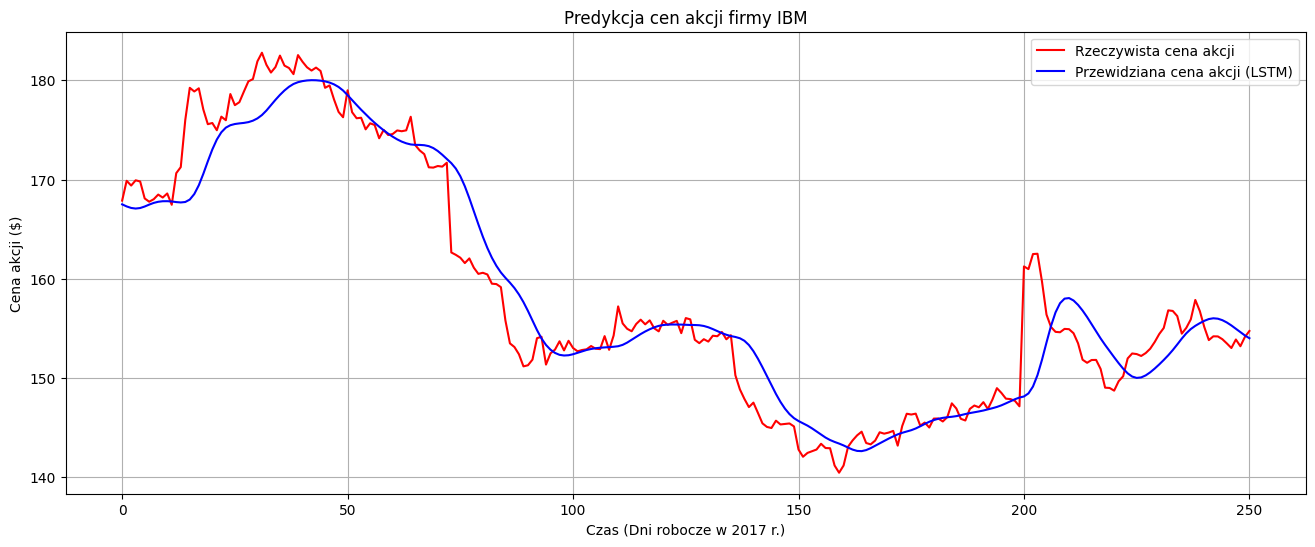

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout

# ==============================================================================
# 1. WCZYTANIE I PRZYGOTOWANIE DANYCH
# ==============================================================================
# Możesz zmienić nazwę pliku na 'AMZN_2006-01-01_to_2018-01-01.csv' lub 'GOOGL_2006-01-01_to_2018-01-01.csv'
file_name = 'IBM_2006-01-01_to_2018-01-01.csv'
dataset = pd.read_csv(file_name, index_col='Date', parse_dates=['Date'])

# Podział na zbiór treningowy (do roku 2016 włącznie) i testowy (rok 2017)
training_set = dataset[:'2016'].iloc[:, 1:2].values
test_set = dataset['2017':].iloc[:, 1:2].values

# Sprawdzenie kształtu danych
print(f"Kształt zbioru treningowego: {training_set.shape}")
print(f"Kształt zbioru testowego: {test_set.shape}")

# Wizualizacja bazowa (opcjonalna)
dataset["High"][:'2016'].plot(figsize=(16, 4), legend=True)
dataset["High"]['2017':].plot(figsize=(16, 4), legend=True)
plt.legend(['Zbiór treningowy (Do 2016)', 'Zbiór testowy (2017)'])
plt.title(f'Ceny akcji - {file_name.split("_")[0]}')
plt.show()

# Skalowanie danych do przedziału (0, 1)
sc = MinMaxScaler(feature_range=(0, 1))
training_set_scaled = sc.fit_transform(training_set)

# Tworzenie struktury danych z 60 krokami czasowymi (patrzymy 60 dni w tył)
X_train = []
y_train = []
for i in range(60, len(training_set_scaled)):
    X_train.append(training_set_scaled[i-60:i, 0])
    y_train.append(training_set_scaled[i, 0])

X_train, y_train = np.array(X_train), np.array(y_train)

# Zmiana kształtu danych na format akceptowany przez LSTM: [samples, time steps, features]
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

# ==============================================================================
# 2. BUDOWA I TRENING MODELU LSTM
# ==============================================================================
regressor = Sequential()

# Pierwsza warstwa LSTM + Dropout
regressor.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
regressor.add(Dropout(0.2))

# Druga warstwa LSTM + Dropout
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))

# Trzecia warstwa LSTM + Dropout
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))

# Czwarta warstwa LSTM + Dropout
regressor.add(LSTM(units=50))
regressor.add(Dropout(0.2))

# Warstwa wyjściowa (Dense) zwracająca jedną wartość (przewidywaną cenę)
regressor.add(Dense(units=1))

# Kompilacja modelu
regressor.compile(optimizer='rmsprop', loss='mean_squared_error')

# Trenowanie sieci
print("\n--- Rozpoczęcie uczenia sieci LSTM ---")
regressor.fit(X_train, y_train, epochs=25, batch_size=32)

# ==============================================================================
# 3. PREDYKCJA I WIZUALIZACJA WYNIKÓW
# ==============================================================================
# Przygotowanie danych testowych (potrzebujemy ostatnich 60 dni ze zbioru treningowego)
dataset_total = pd.concat((dataset["High"][:'2016'], dataset["High"]['2017':]), axis=0)
inputs = dataset_total[len(dataset_total) - len(test_set) - 60:].values
inputs = inputs.reshape(-1, 1)
inputs = sc.transform(inputs)

# Tworzenie sekwencji testowych
X_test = []
for i in range(60, len(inputs)):
    X_test.append(inputs[i-60:i, 0])
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# Generowanie przewidywań przez model
predicted_stock_price = regressor.predict(X_test)
# Odwrócenie skalowania, aby wrócić do realnych cen w dolarach
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

# Funkcja pomocnicza do rysowania wykresu wyników
def plot_predictions(test, predicted, company_name):
    plt.figure(figsize=(16, 6))
    plt.plot(test, color='red', label='Rzeczywista cena akcji')
    plt.plot(predicted, color='blue', label='Przewidziana cena akcji (LSTM)')
    plt.title(f'Predykcja cen akcji firmy {company_name}')
    plt.xlabel('Czas (Dni robocze w 2017 r.)')
    plt.ylabel('Cena akcji ($)')
    plt.legend()
    plt.grid(True)
    plt.show()

# Wyświetlenie końcowego wykresu
plot_predictions(test_set, predicted_stock_price, file_name.split("_")[0])

In [2]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful